In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading in the dataframe from a file
df = pd.read_csv("Zomato-data-.csv")
# Then locate the first 5 rows
print(df.loc[0:4])

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [3]:
df.rename(columns={'name': 'Restaurant Name',
                  'online_order': 'Online Availability',
                  'book_table': 'Booking Availability',
                  'rate': 'Rating',
                  'votes': 'Rating Count',
                  'approx_cost(for two people)': 'Approximate Two Person Cost',
                  'listed_in(type)': 'Restaurant Type'}, inplace=True)
print(df.loc[0:4])

         Restaurant Name Online Availability Booking Availability Rating  \
0                  Jalsa                 Yes                  Yes  4.1/5   
1         Spice Elephant                 Yes                   No  4.1/5   
2        San Churro Cafe                 Yes                   No  3.8/5   
3  Addhuri Udupi Bhojana                  No                   No  3.7/5   
4          Grand Village                  No                   No  3.8/5   

   Rating Count  Approximate Two Person Cost Restaurant Type  
0           775                          800          Buffet  
1           787                          800          Buffet  
2           918                          800          Buffet  
3            88                          300          Buffet  
4           166                          600          Buffet  


In [4]:
# Drop zeros
df = df.drop(df[df['Rating Count'] == 0].index)

In [5]:
def frac2float(frac):
    """
    Converts a fraction object into a float

    Parameters:
        frac (object): a fraction, whose string looks like 'X/Y'

    Returns:
        float: the decimal value of the fraction
    """
    # make the fraction into a string:
    f = str(frac)
    # split the string around the "/" symbol:
    f = f.split("/")
    # convert each part to floats take only the first
    f = float(f[0])
    return f
# Now apply the function to the rates column and see that rates are now floats:
df['Rating'] = df['Rating'].apply(frac2float)
print(df['Rating'].loc[0:4])

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: Rating, dtype: float64


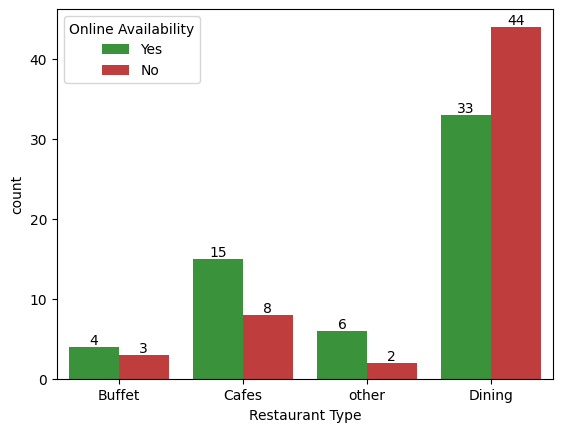

In [39]:
ax = sns.countplot(data=df, x='Restaurant Type', hue='Online Availability', palette=["C2", "C3"])
for lbl in ax.containers:
    ax.bar_label(lbl)

From this graph we can see that the majority of restaurants that offer Zomato fall into the Dining category.

Text(0.5, 1.0, 'Average Number of Votes by Restaurant Type')

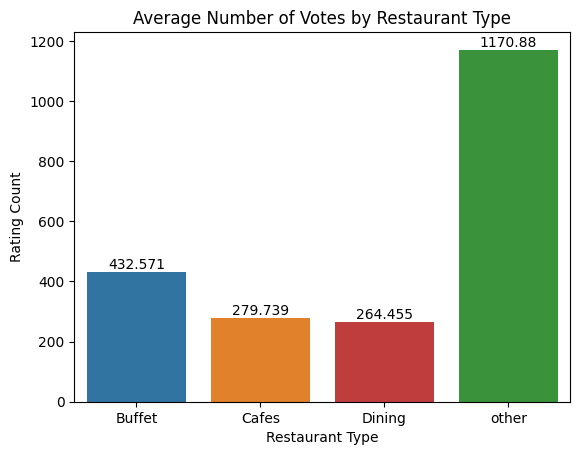

In [37]:
## Now let's look at average rating by restaurant type
# first group the dataframe into a new one:
votesByType = df.groupby('Restaurant Type')['Rating Count'].mean()
votesByType = pd.DataFrame({'Rating Count': votesByType})
# then plot it
ax = sns.barplot(votesByType, x='Restaurant Type', y='Rating Count', hue='Restaurant Type', 
                 palette=["C0", "C1", "C3", "C2"], order=['Buffet','Cafes','Dining','other'])
for lbl in ax.containers:
    ax.bar_label(lbl)
plt.title("Average Number of Votes by Restaurant Type")

From this bar plot we see that the 'other' category restaurants generally receive many more votes than the Buffet, Cafe, or Dining restaurant types.

In [27]:
new = df.groupby(['Restaurant Type','Online Availability']).size()
print(new)

Restaurant Type  Online Availability
Buffet           No                      3
                 Yes                     4
Cafes            No                      8
                 Yes                    15
Dining           No                     44
                 Yes                    33
other            No                      2
                 Yes                     6
dtype: int64


In [46]:
df['Rating'].quantile(0.1)

np.float64(3.14)

<Axes: xlabel='Approximate Two Person Cost', ylabel='log Rating Count'>

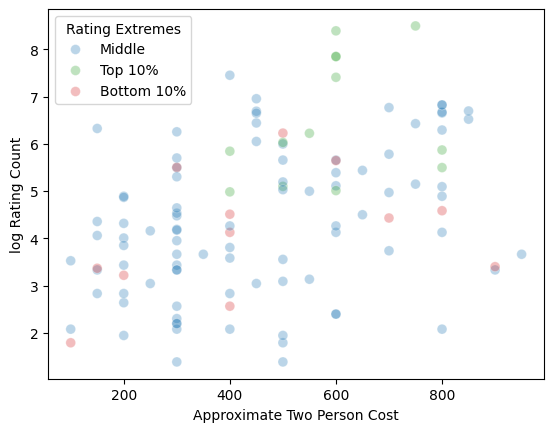

In [51]:
df['Rating Extremes'] = df['Rating'].apply(lambda x: 'Top 10%' 
                                           if x >= df['Rating'].quantile(0.9) 
                                           else 'Bottom 10%' if x <= df['Rating'].quantile(0.1)
                                           else 'Middle')
sns.scatterplot(data=df, x='Approximate Two Person Cost', y='log Rating Count', alpha=0.3, s=50, hue='Rating Extremes', palette=["C0", "C2", "C3"])

<Axes: xlabel='Rating', ylabel='log Rating Count'>

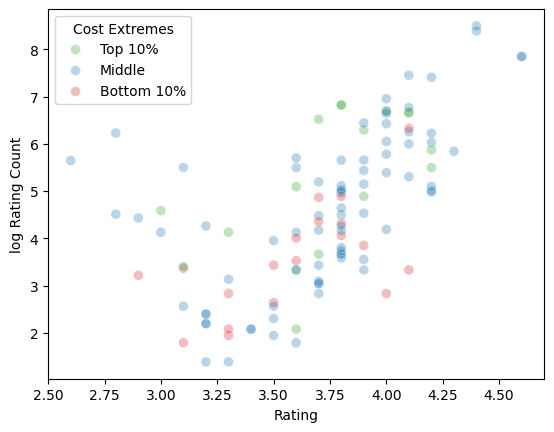

In [57]:
df['Cost Extremes'] = df['Approximate Two Person Cost'].apply(lambda x: 'Top 10%' 
                                           if x >= df['Approximate Two Person Cost'].quantile(0.9) 
                                           else 'Bottom 10%' if x <= df['Approximate Two Person Cost'].quantile(0.1)
                                           else 'Middle')
sns.scatterplot(data=df, x='Rating', y='log Rating Count', alpha=0.3, s=50, hue='Cost Extremes', palette=["C2", "C0", "C3"])

<Axes: xlabel='Rating', ylabel='log Rating Count'>

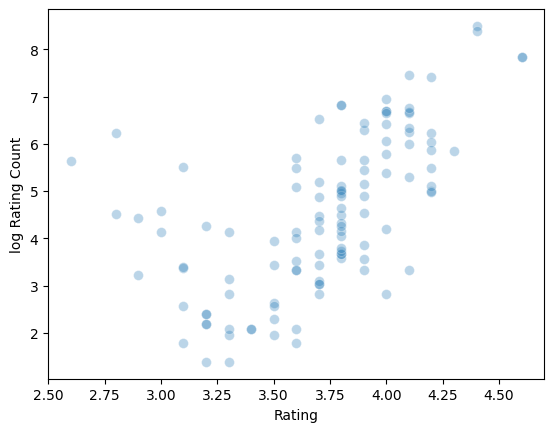

In [22]:
df['log Rating Count'] = np.log(df['Rating Count'])
sns.scatterplot(data=df, x='Rating', y='log Rating Count', alpha=0.3, s=50)

Text(0.5, 1.0, 'Distribution of Two Person Dining Cost by Restaurant Type')

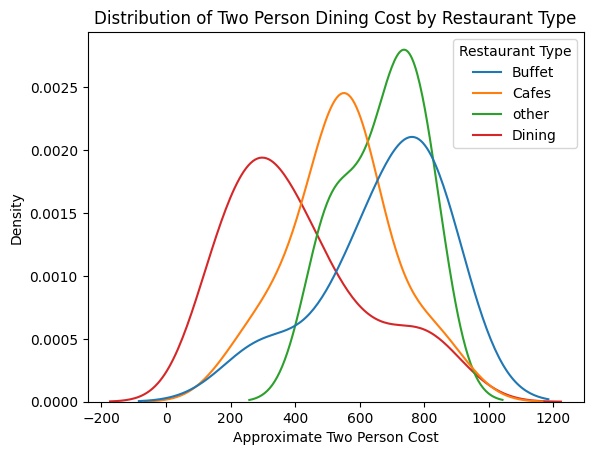

In [17]:
## Now let's plot the occurences of approximate cost for 2 people
sns.kdeplot(df, x='Approximate Two Person Cost', hue='Restaurant Type', palette=["C0", "C1", "C2", "C3"], common_norm=False)
plt.title("Distribution of Two Person Dining Cost by Restaurant Type")

Text(0.5, 1.0, 'Box Plot Distribution of Rating Accounting for Online Availability')

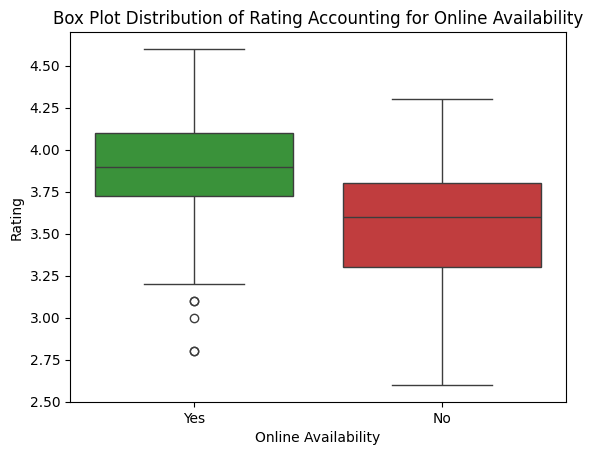

In [18]:
sns.boxplot(df, x='Online Availability', y='Rating', hue='Online Availability', palette=["C2", "C3"])
plt.title("Box Plot Distribution of Rating Accounting for Online Availability")

Text(0.5, 1.0, 'Box Plot Distribution of Rating Accounting for Booking Availability')

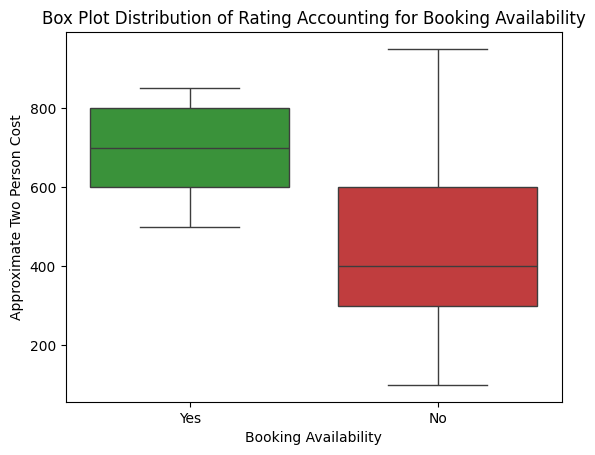

In [60]:
sns.boxplot(df, x='Booking Availability', y='Approximate Two Person Cost', hue='Booking Availability', palette=["C2", "C3"])
plt.title("Box Plot Distribution of Rating Accounting for Booking Availability")